# Experiment 5.2 — Frozen Local → FF/RSNN, $\tau_R$ sweep

Analysis-only notebook. Training and Slurm orchestration live under `scripts/`. The notebook never selects on test BA.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ARTIFACT_ROOT = REPO_ROOT / 'notebooks' / 'artifacts' / 'experiment_5_2_frozen_local_tauR_sweep' / 'frozen_exp3_l2_endpoint_tauR_v1'
runs = pd.read_csv(ARTIFACT_ROOT / 'runs.csv')
histories = pd.read_csv(ARTIFACT_ROOT / 'histories.csv')
local_reference = pd.read_csv(ARTIFACT_ROOT / 'local_reference.csv')
manifest = json.loads((ARTIFACT_ROOT / 'manifest.json').read_text(encoding='utf-8'))
assert len(runs) == manifest['expected_decoder_runs'] == 50
runs.head()


,architecture,shift_mem_r,tau_mem_r_ms,seed,best_epoch,native_train_accuracy,native_train_balanced_accuracy,native_train_macro_f1,native_train_loss,native_train_hidden_events_per_neuron_second,...,hidden_whole_count_C,hidden_fixed250_ordered_val_ba,hidden_fixed250_ordered_test_ba,hidden_fixed250_ordered_C,hidden_relative10_ordered_val_ba,hidden_relative10_ordered_test_ba,hidden_relative10_ordered_C,hidden_uend_val_ba,hidden_uend_test_ba,hidden_uend_C
0,ff,3,117.013683,11,15,0.750430,0.748439,0.751831,0.809803,10.604276,...,1.000,0.534800,0.587030,1.00,0.632660,0.673608,0.010,0.485035,0.494439,0.10
1,ff,3,117.013683,23,54,0.912220,0.914396,0.914833,0.335541,11.543194,...,1.000,0.560101,0.602730,1.00,0.636033,0.677538,0.010,0.509145,0.522686,0.10
2,ff,3,117.013683,37,20,0.757315,0.758551,0.760468,0.739091,10.544928,...,0.001,0.561316,0.568525,0.01,0.629509,0.615657,0.001,0.506656,0.473655,0.01
3,ff,3,117.013683,53,28,0.786575,0.787273,0.787836,0.617295,12.100164,...,0.100,0.523521,0.636519,0.01,0.618573,0.606299,0.100,0.507756,0.500344,0.01
4,ff,3,117.013683,71,33,0.814114,0.814647,0.816267,0.597045,10.754443,...,1.000,0.555008,0.537218,1.00,0.625048,0.654346,0.100,0.470851,0.477567,1.00


## 1. Validation-only summary and $\tau_R$ selection

The RSNN tau is selected by **mean validation native endpoint BA**. Test BA is only reported after that selection.


In [2]:
summary = (
    runs.groupby(['architecture', 'shift_mem_r', 'tau_mem_r_ms'], as_index=False)
    .agg(
        val_ba_mean=('native_val_balanced_accuracy', 'mean'),
        val_ba_sd=('native_val_balanced_accuracy', 'std'),
        test_ba_mean=('native_test_balanced_accuracy', 'mean'),
        test_ba_sd=('native_test_balanced_accuracy', 'std'),
        test_macro_f1_mean=('native_test_macro_f1', 'mean'),
        hidden_rate_mean=('native_test_hidden_events_per_neuron_second', 'mean'),
        tail_fraction_mean=('native_test_hidden_tail_event_fraction', 'mean'),
        endpoint_norm_mean=('native_test_endpoint_membrane_l2_mean', 'mean'),
    )
)
rsnn_summary = summary[summary['architecture'] == 'rsnn'].copy()
best_row = rsnn_summary.sort_values(['val_ba_mean', 'tau_mem_r_ms'], ascending=[False, True]).iloc[0]
selected_rsnn_shift = int(best_row['shift_mem_r'])
selected_rsnn_tau_ms = float(best_row['tau_mem_r_ms'])
selected_rsnn = runs[(runs['architecture'] == 'rsnn') & (runs['shift_mem_r'] == selected_rsnn_shift)].copy()
print(f'Validation-selected RSNN: shift={selected_rsnn_shift}, tau={selected_rsnn_tau_ms:.1f} ms')
print(f'Selected test BA: {selected_rsnn.native_test_balanced_accuracy.mean():.4f} ± {selected_rsnn.native_test_balanced_accuracy.std():.4f}')
summary


Validation-selected RSNN: shift=5, tau=492.1 ms
Selected test BA: 0.5384 ± 0.0245


,architecture,shift_mem_r,tau_mem_r_ms,val_ba_mean,val_ba_sd,test_ba_mean,test_ba_sd,test_macro_f1_mean,hidden_rate_mean,tail_fraction_mean,endpoint_norm_mean
0,ff,3,117.013683,0.493344,0.024446,0.483548,0.026881,0.483724,11.697333,0.008607,23.384155
1,ff,4,242.103471,0.516946,0.013555,0.506831,0.029673,0.508570,12.047109,0.017233,38.395575
2,ff,5,492.146161,0.533300,0.027953,0.532709,0.017519,0.532169,12.119558,0.028105,59.066198
3,ff,6,992.166994,0.546806,0.028656,0.536135,0.027117,0.533000,12.190159,0.038449,79.689543
4,ff,7,1992.177288,0.557910,0.026172,0.523494,0.023350,0.518696,11.996902,0.044380,93.920819
5,rsnn,3,117.013683,0.542641,0.029972,0.531488,0.018048,0.531103,17.697888,0.511471,37.519856
6,rsnn,4,242.103471,0.573415,0.021823,0.561311,0.033342,0.557237,16.400505,0.514186,61.407726
7,rsnn,5,492.146161,0.576277,0.013373,0.538417,0.024516,0.536176,15.178148,0.515468,98.075469
8,rsnn,6,992.166994,0.553605,0.032183,0.536060,0.035870,0.532733,14.271943,0.481316,129.622268
9,rsnn,7,1992.177288,0.548948,0.027719,0.521373,0.039680,0.508676,13.487806,0.511366,173.433077


## 2. Local information reference levels

These are computed from the exact same frozen L2 trajectory before any FF/RSNN decoder.


In [3]:
local_ref_summary = (
    local_reference.groupby('probe_type', as_index=False)
    .agg(val_ba_mean=('val_ba', 'mean'), val_ba_sd=('val_ba', 'std'), test_ba_mean=('test_ba', 'mean'), test_ba_sd=('test_ba', 'std'))
)
local_ref_summary


,probe_type,val_ba_mean,val_ba_sd,test_ba_mean,test_ba_sd
0,local_fixed250_ordered,0.568466,0.025447,0.625055,0.025606
1,local_relative10_ordered,0.632544,0.013030,0.689499,0.033622
2,local_whole_count,0.532827,0.017350,0.543896,0.028094


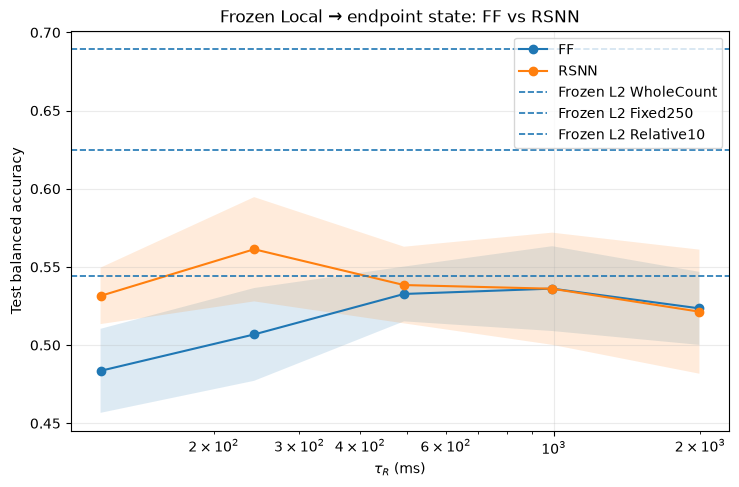

In [4]:
ref = local_ref_summary.set_index('probe_type')['test_ba_mean']
fig, ax = plt.subplots(figsize=(8.5, 5.2))
for architecture, group in summary.groupby('architecture'):
    group = group.sort_values('tau_mem_r_ms')
    ax.plot(group['tau_mem_r_ms'], group['test_ba_mean'], marker='o', label=architecture.upper())
    ax.fill_between(
        group['tau_mem_r_ms'],
        group['test_ba_mean'] - group['test_ba_sd'],
        group['test_ba_mean'] + group['test_ba_sd'],
        alpha=0.15,
    )
for probe_type, label in [
    ('local_whole_count', 'Frozen L2 WholeCount'),
    ('local_fixed250_ordered', 'Frozen L2 Fixed250'),
    ('local_relative10_ordered', 'Frozen L2 Relative10'),
]:
    if probe_type in ref.index:
        ax.axhline(ref.loc[probe_type], linestyle='--', linewidth=1.2, label=label)
ax.set_xscale('log')
ax.set_xlabel(r'$\tau_R$ (ms)')
ax.set_ylabel('Test balanced accuracy')
ax.set_title('Frozen Local → endpoint state: FF vs RSNN')
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## 3. Paired recurrence contribution

For each seed and matched tau, compute `RSNN - FF`.


In [5]:
paired = runs.pivot_table(
    index=['seed', 'shift_mem_r', 'tau_mem_r_ms'],
    columns='architecture',
    values=['native_val_balanced_accuracy', 'native_test_balanced_accuracy'],
).reset_index()
paired.columns = ['_'.join([str(x) for x in col if str(x)]) if isinstance(col, tuple) else str(col) for col in paired.columns]
paired['rsnn_minus_ff_val'] = paired['native_val_balanced_accuracy_rsnn'] - paired['native_val_balanced_accuracy_ff']
paired['rsnn_minus_ff_test'] = paired['native_test_balanced_accuracy_rsnn'] - paired['native_test_balanced_accuracy_ff']
paired_effects = (
    paired.groupby(['shift_mem_r', 'tau_mem_r_ms'], as_index=False)
    .agg(
        val_effect_mean=('rsnn_minus_ff_val', 'mean'),
        val_effect_sd=('rsnn_minus_ff_val', 'std'),
        test_effect_mean=('rsnn_minus_ff_test', 'mean'),
        test_effect_sd=('rsnn_minus_ff_test', 'std'),
        positive_test_seeds=('rsnn_minus_ff_test', lambda s: int((s > 0).sum())),
    )
)
paired_effects


,shift_mem_r,tau_mem_r_ms,val_effect_mean,val_effect_sd,test_effect_mean,test_effect_sd,positive_test_seeds
0,3,117.013683,0.049297,0.033403,0.047940,0.032313,4
1,4,242.103471,0.056469,0.014375,0.054480,0.017958,5
2,5,492.146161,0.042977,0.025655,0.005708,0.033109,4
3,6,992.166994,0.006799,0.017544,-0.000075,0.028119,3
4,7,1992.177288,-0.008962,0.024077,-0.002121,0.049458,3


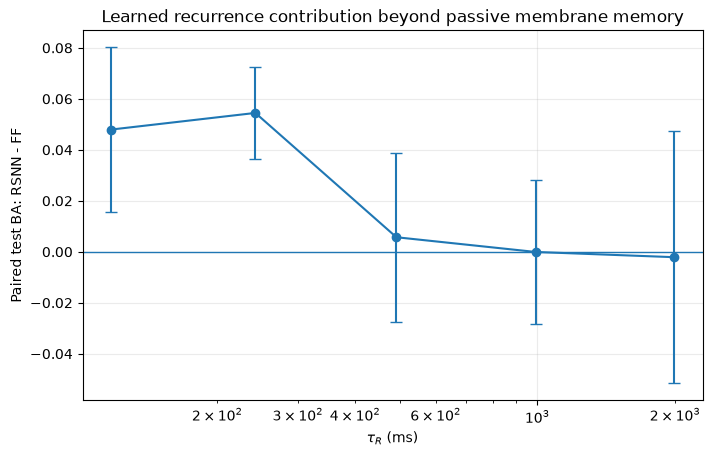

In [6]:
fig, ax = plt.subplots(figsize=(8.0, 4.8))
ax.axhline(0.0, linewidth=1.0)
ax.errorbar(paired_effects['tau_mem_r_ms'], paired_effects['test_effect_mean'], yerr=paired_effects['test_effect_sd'], marker='o', capsize=4)
ax.set_xscale('log')
ax.set_xlabel(r'$\tau_R$ (ms)')
ax.set_ylabel('Paired test BA: RSNN - FF')
ax.set_title('Learned recurrence contribution beyond passive membrane memory')
ax.grid(alpha=0.25)
plt.show()


## 4. Hidden-state readout matrix for validation-selected conditions


In [7]:
selected_ff_shift = int(
    summary[summary['architecture'] == 'ff'].sort_values(['val_ba_mean', 'tau_mem_r_ms'], ascending=[False, True]).iloc[0]['shift_mem_r']
)
selected_conditions = pd.concat([
    runs[(runs['architecture'] == 'ff') & (runs['shift_mem_r'] == selected_ff_shift)],
    runs[(runs['architecture'] == 'rsnn') & (runs['shift_mem_r'] == selected_rsnn_shift)],
])
probe_cols = [
    'hidden_whole_count_test_ba',
    'hidden_fixed250_ordered_test_ba',
    'hidden_relative10_ordered_test_ba',
    'hidden_uend_test_ba',
]
readout_matrix = selected_conditions.groupby(['architecture', 'shift_mem_r', 'tau_mem_r_ms'])[probe_cols].agg(['mean', 'std'])
readout_matrix


hidden_whole_count_test_ba            \
                                                            mean       std   
architecture shift_mem_r tau_mem_r_ms                                        
ff           7           1992.177288                    0.517453  0.025998   
rsnn         5           492.146161                     0.491951  0.023802   

                                      hidden_fixed250_ordered_test_ba  \
                                                                 mean   
architecture shift_mem_r tau_mem_r_ms                                   
ff           7           1992.177288                         0.556206   
rsnn         5           492.146161                          0.521431   

                                                 \
                                            std   
architecture shift_mem_r tau_mem_r_ms             
ff           7           1992.177288   0.021346   
rsnn         5           492.146161    0.018579   

                                      hidden_relative10_ordered_test_ba  \
                                                                   mean   
architecture shift_mem_r tau_mem_r_ms                                     
ff           7           1992.177288                           0.617616   
rsnn         5           492.146161                            0.588736   

                                                hidden_uend_test_ba            
                                            std                mean       std  
architecture shift_mem_r tau_mem_r_ms                                          
ff           7           1992.177288   0.043772            0.572117  0.051231  
rsnn         5           492.146161    0.032305            0.583820  0.026334

## 5. Timing recovery and Fixed250 gap

`timing_recovery = (Uend - LocalCount) / (LocalRelative10 - LocalCount)`. It is intentionally not clipped.


In [8]:
ref_per_seed = local_reference.pivot(index='seed', columns='probe_type', values='test_ba')
diag = runs.merge(ref_per_seed, left_on='seed', right_index=True, how='left')
diag['timing_recovery'] = (
    diag['hidden_uend_test_ba'] - diag['local_whole_count']
) / (diag['local_relative10_ordered'] - diag['local_whole_count'])
diag['fixed250_gap'] = diag['local_fixed250_ordered'] - diag['hidden_uend_test_ba']
diagnostic_summary = (
    diag.groupby(['architecture', 'shift_mem_r', 'tau_mem_r_ms'], as_index=False)
    .agg(
        timing_recovery_mean=('timing_recovery', 'mean'),
        timing_recovery_sd=('timing_recovery', 'std'),
        fixed250_gap_mean=('fixed250_gap', 'mean'),
        fixed250_gap_sd=('fixed250_gap', 'std'),
    )
)
diagnostic_summary


,architecture,shift_mem_r,tau_mem_r_ms,timing_recovery_mean,timing_recovery_sd,fixed250_gap_mean,fixed250_gap_sd
0,ff,3,117.013683,-0.444452,0.506862,0.131317,0.033422
1,ff,4,242.103471,-0.167760,0.404732,0.097615,0.046918
2,ff,5,492.146161,-0.046557,0.453713,0.073740,0.032211
3,ff,6,992.166994,0.152966,0.415518,0.053258,0.048256
4,ff,7,1992.177288,0.095949,0.689817,0.052938,0.047527
5,rsnn,3,117.013683,-0.050475,0.428296,0.083026,0.048905
6,rsnn,4,242.103471,0.160733,0.439681,0.049603,0.032412
7,rsnn,5,492.146161,0.250152,0.339810,0.041234,0.041317
8,rsnn,6,992.166994,0.096991,0.514740,0.056335,0.036060
9,rsnn,7,1992.177288,0.092487,0.510521,0.071400,0.070961


## 6. Validation learning curves for validation-selected FF and RSNN


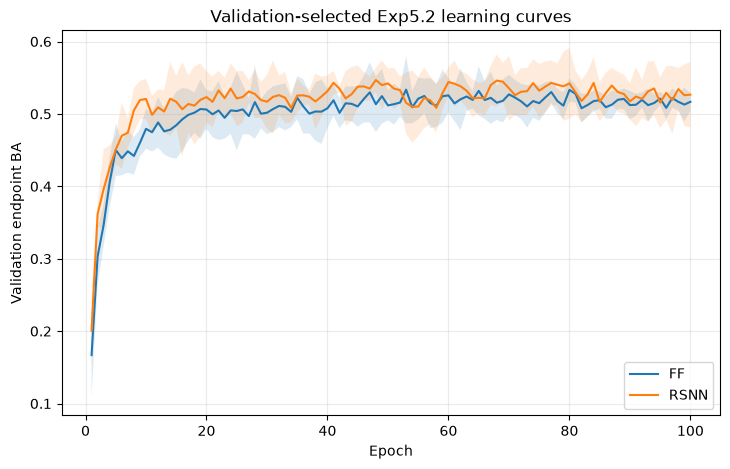

In [9]:
selected_hist = histories[
    ((histories['architecture'] == 'ff') & (histories['shift_mem_r'] == selected_ff_shift))
    | ((histories['architecture'] == 'rsnn') & (histories['shift_mem_r'] == selected_rsnn_shift))
].copy()
curve = selected_hist.groupby(['architecture', 'epoch'], as_index=False).agg(
    val_ba_mean=('val_balanced_accuracy', 'mean'),
    val_ba_sd=('val_balanced_accuracy', 'std'),
)
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for architecture, group in curve.groupby('architecture'):
    group = group.sort_values('epoch')
    ax.plot(group['epoch'], group['val_ba_mean'], label=architecture.upper())
    ax.fill_between(group['epoch'], group['val_ba_mean'] - group['val_ba_sd'], group['val_ba_mean'] + group['val_ba_sd'], alpha=0.15)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation endpoint BA')
ax.set_title('Validation-selected Exp5.2 learning curves')
ax.legend()
ax.grid(alpha=0.25)
plt.show()


## Interpretation checklist

- `FF(long tau) > FF(short tau)`: passive membrane persistence helps.
- `RSNN(tau) > FF(tau)`: learned recurrence contributes beyond passive memory.
- `hidden_relative10_ordered >> hidden_uend`: informative trajectory exists but endpoint consolidation remains incomplete.
- `hidden_uend ≈ local_fixed250_ordered`: recurrent endpoint state recovers most information that previously required explicit phase-addressed storage.
- Long tau with rising tail fraction: accuracy gain may be coupled to unstable autonomous persistence.
